<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/catVdog_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import torch

torch.__version__

'2.10.0+cu128'

In [28]:
from pathlib import Path

data = Path("/content/drive/MyDrive/animals (1)")
data

PosixPath('/content/drive/MyDrive/animals (1)')

In [29]:
train_path = data/"Train"
test_path = data/"Test"
train_path, test_path

(PosixPath('/content/drive/MyDrive/animals (1)/Train'),
 PosixPath('/content/drive/MyDrive/animals (1)/Test'))

In [30]:
import os

for dirpath, dirnames, filenames in os.walk(data):
  print(f"dirpath - {len(dirpath)}, dirnames - {dirnames}, filenames - {len(filenames)}")

dirpath - 34, dirnames - ['Test', 'Train'], filenames - 0
dirpath - 39, dirnames - ['dog', 'cat'], filenames - 0
dirpath - 43, dirnames - [], filenames - 100
dirpath - 43, dirnames - [], filenames - 100
dirpath - 40, dirnames - ['dog', 'cat'], filenames - 0
dirpath - 44, dirnames - [], filenames - 400
dirpath - 44, dirnames - [], filenames - 400


In [38]:
all_images = list(data.glob("*/*/*.png"))
len(all_images)

1000

In [39]:
import matplotlib.pyplot as plt
import random

rand_file_paths = random.sample(all_images, k=3)
rand_file_paths

[PosixPath('/content/drive/MyDrive/animals (1)/Train/cat/00208-200124518.png'),
 PosixPath('/content/drive/MyDrive/animals (1)/Train/cat/00496-200124806.png'),
 PosixPath('/content/drive/MyDrive/animals (1)/Train/cat/00167-200124477.png')]

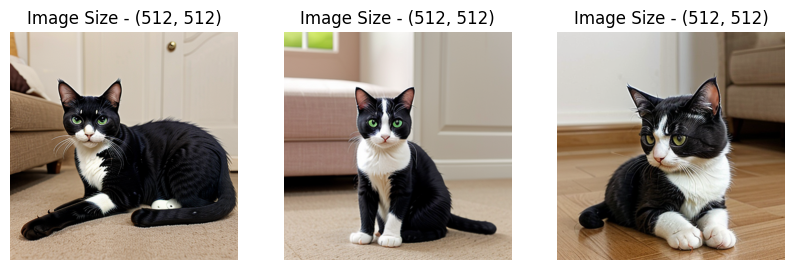

In [40]:
from PIL import Image

fig, ax = plt.subplots(1, 3, figsize=(10,5))

for i, i_path in enumerate(rand_file_paths):
  img = Image.open(i_path)
  ax[i].imshow(img)
  ax[i].axis("off")
  ax[i].set_title(f"Image Size - {img.size}")

plt.show()

In [41]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAutocontrast(p=0.3)
])
data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAutocontrast(p=0.3)
)

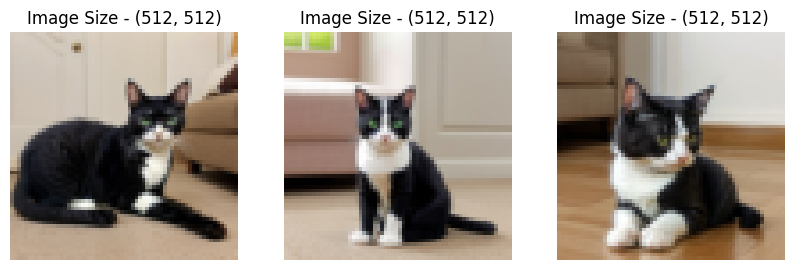

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(10,5))

for i, i_path in enumerate(rand_file_paths):
  img = Image.open(i_path)
  trans_img = data_transform(img)
  ax[i].imshow(trans_img)
  ax[i].axis("off")
  ax[i].set_title(f"Image Size - {img.size}")

plt.show()

In [43]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAutocontrast(p=0.3),
    transforms.ToTensor()
])
data_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomAutocontrast(p=0.3)
    ToTensor()
)

In [44]:
train_dataset = datasets.ImageFolder(train_path, transform=data_transform)
test_dataset = datasets.ImageFolder(test_path, transform=data_transform)

In [45]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 800
     Root location: /content/drive/MyDrive/animals (1)/Train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomAutocontrast(p=0.3)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 200
     Root location: /content/drive/MyDrive/animals (1)/Test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                RandomAutocontrast(p=0.3)
                ToTensor()
            ))

In [46]:
classes = train_dataset.classes
classes

['cat', 'dog']

In [47]:
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [48]:
B_image, B_label = next(iter(train_dataloader))
B_image.shape, B_label

(torch.Size([32, 3, 64, 64]),
 tensor([1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 0, 0, 1, 0, 1, 1, 1]))

In [49]:
from prompt_toolkit import output
from torch import nn

class TinnyVGG(nn.Module):
  def __init__(self, input_u, output_u, hidden_u):
    super().__init__()
    self.convlayer = nn.Sequential(
        nn.Conv2d(input_u, hidden_u, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.Conv2d(hidden_u, hidden_u, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.convlayer2 = nn.Sequential(
        nn.Conv2d(hidden_u, hidden_u, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.Conv2d(hidden_u, hidden_u, kernel_size=3, stride=1),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.linear_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(hidden_u*13*13, output_u)
    )
  def forward(self, x):
    x = self.convlayer(x)
    #print(f"shape - {x.shape}")
    x = self.convlayer2(x)
    #print(f"shape - {x.shape}")
    x = self.linear_layer(x)
    return x

input_u = 3
output_u = 1
hidden_u = 10

In [50]:
model = TinnyVGG(input_u, output_u, hidden_u)
model

TinnyVGG(
  (convlayer): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convlayer2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=1, bias=True)
  )
)

In [51]:
print(B_image[0].shape)
test_img = B_image[0].unsqueeze(0)
test_img.shape

torch.Size([3, 64, 64])


torch.Size([1, 3, 64, 64])

In [52]:
with torch.inference_mode():
  pred = model(test_img)

pred

tensor([[0.0332]])

In [53]:
torch.round(torch.sigmoid(pred))

tensor([[1.]])

In [54]:
def accuracy_Fn(yt, yp):
  t = torch.eq(yt, yp).sum().item()
  a = (t/len(yt)) * 100
  return a

accuracy_Fn(torch.Tensor([0, 1, 2]), torch.Tensor([0, 1, 2]))

100.0

In [60]:
from torch.nn import BCEWithLogitsLoss
from torch.optim import Adam

criterion = BCEWithLogitsLoss()
optimizer = Adam(params=model.parameters(), lr=0.1)

In [56]:
from tqdm import tqdm

In [57]:
EPOCH = []
TA = []
TL = []

In [61]:
for epoch in tqdm(range(10)):
  model.train()
  train_acc = 0
  train_loss = 0
  for image, label in train_dataloader:
    logits = model(image)
    pred = torch.round(torch.sigmoid(logits))
    loss = criterion(logits.squeeze(), label.float())
    acc = accuracy_Fn(pred, label)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_acc += (acc/len(train_dataloader))
  train_loss += (loss/len(train_dataloader))

  if epoch % 2 == 0:
    print(f"\n__Epoch__{epoch}\n")
    print(f"Training Accuracy: {train_acc:.2f} || Training Loss: {train_loss:.5f}")
    EPOCH.append(epoch)
    TA.append(train_acc)
    TL.append(train_loss)

 10%|█         | 1/10 [00:15<02:21, 15.70s/it]


__Epoch__0

Training Accuracy: 56.00 || Training Loss: 0.02809


 30%|███       | 3/10 [00:45<01:46, 15.17s/it]


__Epoch__2

Training Accuracy: 80.00 || Training Loss: 0.02762


 50%|█████     | 5/10 [01:15<01:15, 15.00s/it]

...

 70%|███████   | 7/10 [01:45<00:44, 14.94s/it]


__Epoch__6

Training Accuracy: 56.00 || Training Loss: 0.02796


 90%|█████████ | 9/10 [02:14<00:14, 14.79s/it]


__Epoch__8

Training Accuracy: 76.00 || Training Loss: 0.02767


100%|██████████| 10/10 [02:29<00:00, 14.92s/it]


In [62]:
IMAGE, LABEL = next(iter(test_dataloader))

In [63]:
testImage = IMAGE[0].unsqueeze(0)
LABEL[0], testImage.shape

(tensor(0), torch.Size([1, 3, 64, 64]))

In [64]:
with torch.inference_mode():
  pred = model(testImage)

PREDICTION = torch.round(torch.sigmoid(pred))
PREDICTION

tensor([[0.]])